In [1]:
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

Setting configurations for the model such as hyperparameters and the prepared splits of data from the preprocessing

In [7]:
# =========================================================
# --- Configuration ---
# =========================================================
VARIANT = "bivariate"  # or 'univariate', 'bivariate'
DATA_DIR = f"../preprocessing_scripts/preprocessed_classification_proper_split/w12/{VARIANT}"
OUTPUT_DIR = f"results/{VARIANT}_classification_proper_split"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_STEPS = 12
HORIZON = 4
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001
REG_LIMIT = 160  # µg/kg threshold (for reference only)


# =========================================================
# --- Load Datasets ---
# =========================================================
print(f"\n Loading preprocessed data from {DATA_DIR}...")

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print(f"Shapes -> X_train: {X_train.shape}, y_train: {y_train.shape}")
num_features = X_train.shape[2]


 Loading preprocessed data from ../preprocessing_scripts/preprocessed_classification_proper_split/w12/bivariate...
Shapes -> X_train: (1984, 12, 2), y_train: (1984, 4)


In [8]:
# =========================================================
# --- Check for Class Imbalance ---
# =========================================================
print("\n Checking class distribution across horizons...")

for h in range(y_train.shape[1]):  # Loop over horizons
    unique, counts = np.unique(y_train[:, h], return_counts=True)
    total = counts.sum()
    proportions = {int(k): f"{v} ({v/total:.2%})" for k, v in zip(unique, counts)}
    print(f"Horizon t+{h+1}: {proportions}")

# Optionally, flatten across all horizons
y_train_flat = y_train.reshape(-1)
unique, counts = np.unique(y_train_flat, return_counts=True)
print("\nOverall class distribution (all horizons combined):")
for k, v in zip(unique, counts):
    print(f"  Class {k}: {v} ({v/len(y_train_flat):.2%})")



 Checking class distribution across horizons...
Horizon t+1: {0: '1577 (79.49%)', 1: '407 (20.51%)'}
Horizon t+2: {0: '1576 (79.44%)', 1: '408 (20.56%)'}
Horizon t+3: {0: '1575 (79.39%)', 1: '409 (20.61%)'}
Horizon t+4: {0: '1576 (79.44%)', 1: '408 (20.56%)'}

Overall class distribution (all horizons combined):
  Class 0: 6304 (79.44%)
  Class 1: 1632 (20.56%)


Model training

In [9]:
def build_lstm_classifier(input_shape, horizon):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(horizon, activation='sigmoid')  # 4 binary outputs (0–1)
    ])
    model.compile(
        optimizer=RMSprop(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm_classifier((TIME_STEPS, num_features), HORIZON)
model.summary()



# Flatten all horizons for weighting
y_train_flat = y_train.reshape(-1)
classes = np.unique(y_train_flat)

weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)
class_weight_dict = {k: v for k, v in zip(classes, weights)}

print("Class weights:", class_weight_dict)


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

c:\Users\jverduzco\anaconda3\envs\llm-harmful-algal-bloom\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,364 (75.64 KB)

 Trainable params: 19,364 (75.64 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {np.int64(0): np.float64(0.6294416243654822), np.int64(1): np.float64(2.4313725490196076)}
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1346 - loss: 0.5347 - val_accuracy: 0.0525 - val_loss: 0.3802
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2223 - loss: 0.4481 - val_accuracy: 0.0756 - val_loss: 0.3844
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1588 - loss: 0.4395 - val_accuracy: 0.0621 - val_loss: 0.3612
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1714 - loss: 0.4254 - val_accuracy: 0.1354 - val_loss: 0.3611
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2016 - loss: 0.4126 - val_accuracy: 0.0820 - val_loss: 0.3380
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1996 - loss: 0.3997 - val_accuracy: 0.1545 - val_loss: 0.3226
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2067 - loss: 0.3898 - val_accuracy: 0.1672 - val_loss: 0.3219
Epoc

Model evaluation on combined dataset

In [10]:
print("\n📈 Evaluating on test set...")
y_pred = model.predict(X_test)
y_pred_bin = (y_pred > 0.5).astype(int)

# --- Per-horizon metrics ---
for h in range(HORIZON):
    print(f"\n=== Horizon t+{h+1} ===")
    cm = confusion_matrix(y_test[:, h], y_pred_bin[:, h])
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test[:, h], y_pred_bin[:, h], digits=3))

# =========================================================
# --- Save Model and Results ---
# =========================================================
model.save(os.path.join(OUTPUT_DIR, "lstm_classifier.keras"))
np.save(os.path.join(OUTPUT_DIR, "y_pred.npy"), y_pred)
np.save(os.path.join(OUTPUT_DIR, "y_pred_bin.npy"), y_pred_bin)


📈 Evaluating on test set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== Horizon t+1 ===
Confusion Matrix:
[[639   9]
 [ 30  64]]

Classification Report:
              precision    recall  f1-score   support

           0      0.955     0.986     0.970       648
           1      0.877     0.681     0.766        94

    accuracy                          0.947       742
   macro avg      0.916     0.833     0.868       742
weighted avg      0.945     0.947     0.945       742


=== Horizon t+2 ===
Confusion Matrix:
[[632  16]
 [ 40  54]]

Classification Report:
              precision    recall  f1-score   support

           0      0.940     0.975     0.958       648
           1      0.771     0.574     0.659        94

    accuracy                          0.925       742
   macro avg      0.856     0.775     0.808       742
weighted avg      0.919     0.925     0.920       742


=== Horizon t+3 ===
Confusion Matrix:
[[631  17]
 [ 47  47]]

Classification Report:
              preci

Site evaluation at RIAV 1

imports and helper functions

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)
from tensorflow.keras.models import load_model


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)





Configs

In [7]:
# Cell: Configuration
DATA_DIR = "../../preprocessed_classification"      # produced by your classification preprocessing
MODEL_DIR = "results/multivariate_classification" # where model .keras is saved
VARIANT = "multivariate"                         # 'univariate'|'bivariate'|'multivariate'
SITE_ID = "RIAV1"
OUTPUT_DIR = f"eval_{SITE_ID}_{VARIANT}"
ensure_dir(OUTPUT_DIR)

HORIZON = 4
THRESHOLD = 0.5   # probability threshold for classification


Load model

In [8]:
model_path = os.path.join(MODEL_DIR, f"lstm_classifier.keras")
assert os.path.exists(model_path), f"Model not found: {model_path}"
model = load_model(model_path, compile=False)  # compile=False fine for inference
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,412 (83.64 KB)

 Trainable params: 21,412 (83.64 KB)

 Non-trainable params: 0 (0.00 B)

Load data and filter for site specific evaluation

In [9]:
variant_dir = os.path.join(DATA_DIR, VARIANT)
X_test = np.load(os.path.join(variant_dir, "X_test.npy"), allow_pickle=True)
y_test = np.load(os.path.join(variant_dir, "y_test.npy"), allow_pickle=True)
dates_test = np.load(os.path.join(variant_dir, "dates_test.npy"), allow_pickle=True)
site_ids_test = np.load(os.path.join(variant_dir, "site_ids_test.npy"), allow_pickle=True)

mask = (site_ids_test == SITE_ID)
X_site = X_test[mask]
y_site = y_test[mask]
dates_site = dates_test[mask]

print(f"Total test windows for {SITE_ID}: {len(X_site)}")
print("X_site shape:", X_site.shape, "y_site shape:", y_site.shape)

Total test windows for RIAV1: 66
X_site shape: (66, 12, 10) y_site shape: (66, 4)


In [10]:
y_pred_probs = model.predict(X_site, verbose=0)   # shape: (N, HORIZON) or (N, )
# If model outputs (N, ) for single horizon, reshape to (N,1)
if y_pred_probs.ndim == 1:
    y_pred_probs = y_pred_probs.reshape(-1, 1)

# If model outputs 2D but HORIZON differs, check shape
assert y_pred_probs.shape[1] == HORIZON, f"Model output horizon mismatch: {y_pred_probs.shape}"

y_pred_bin = (y_pred_probs >= THRESHOLD).astype(int)
# Save
np.save(os.path.join(OUTPUT_DIR, "y_pred_probs.npy"), y_pred_probs)
np.save(os.path.join(OUTPUT_DIR, "y_pred_bin.npy"), y_pred_bin)

Per horizon classification and confusion matrices

In [13]:
from sklearn.metrics import classification_report

metrics = []
for h in range(HORIZON):
    y_t = y_site[:, h]
    y_p = y_pred_bin[:, h]
    acc = accuracy_score(y_t, y_p)
    prec = precision_score(y_t, y_p, zero_division=0)
    rec = recall_score(y_t, y_p, zero_division=0)
    f1 = f1_score(y_t, y_p, zero_division=0)
    metrics.append({"horizon": f"t+{h+1}", "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    print(f"t+{h+1}: acc={acc:.3f}, prec={prec:.3f}, rec={rec:.3f}, f1={f1:.3f}")
    print(classification_report(y_t, y_p, digits=3))

    # Confusion matrix plot
    cm = confusion_matrix(y_t, y_p, labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No","Yes"])
    fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    ax.set_title(f"{SITE_ID} | {VARIANT} | t+{h+1}")
    fig.savefig(os.path.join(OUTPUT_DIR, f"confusion_{VARIANT}_{SITE_ID}_t{h+1}.png"), bbox_inches='tight', dpi=200)
    plt.close(fig)

# Save metrics table
pd.DataFrame(metrics).to_csv(os.path.join(OUTPUT_DIR, "classification_metrics_per_horizon.csv"), index=False)

t+1: acc=0.848, prec=0.923, rec=0.889, f1=0.906
              precision    recall  f1-score   support

           0      0.571     0.667     0.615        12
           1      0.923     0.889     0.906        54

    accuracy                          0.848        66
   macro avg      0.747     0.778     0.761        66
weighted avg      0.859     0.848     0.853        66

t+2: acc=0.773, prec=0.868, rec=0.852, f1=0.860
              precision    recall  f1-score   support

           0      0.385     0.417     0.400        12
           1      0.868     0.852     0.860        54

    accuracy                          0.773        66
   macro avg      0.626     0.634     0.630        66
weighted avg      0.780     0.773     0.776        66

t+3: acc=0.727, prec=0.846, rec=0.815, f1=0.830
              precision    recall  f1-score   support

           0      0.286     0.333     0.308        12
           1      0.846     0.815     0.830        54

    accuracy                          

In [12]:
# =========================================================
# --- t+1 Classified Observation Time Series (Paper Style) ---
# =========================================================

h = 0  # t+1 horizon

dates = pd.to_datetime(dates_site)

# Continuous observed DSP toxins (not binary)
y_obs = y_site_continuous[:, h]      # <-- actual DSP values
y_pred = y_pred_continuous[:, h]     # <-- predicted DSP values

# Threshold-based events
actual_event = y_obs >= REG_LIMIT
pred_event   = y_pred >= REG_LIMIT

# Correct / incorrect classification
correct = actual_event == pred_event
incorrect = ~correct

fig, ax = plt.subplots(figsize=(14, 3))

# --- Observations (continuous line) ---
ax.plot(
    dates,
    y_obs,
    color="black",
    linewidth=1.2,
    label="Observations"
)

# --- Correct predictions ---
ax.scatter(
    dates[correct],
    y_obs[correct],
    color="#1f78b4",     # blue
    s=22,
    label="Correct predictions",
    zorder=3
)

# --- Incorrect predictions ---
ax.scatter(
    dates[incorrect],
    y_obs[incorrect],
    color="#ffb000",     # orange
    s=22,
    label="Incorrect predictions",
    zorder=3
)

# --- Regulatory limit ---
ax.axhline(
    REG_LIMIT,
    color="gray",
    linestyle="--",
    linewidth=1.0
)

# Formatting (match paper style)
ax.set_ylabel("DSP toxins")
ax.set_xlabel("Date")
ax.set_title(f"{SITE_ID} — Bivariate LSTM — t+1 Classification")

ax.legend(
    loc="upper left",
    ncol=3,
    frameon=False
)

ax.grid(False)

fig.tight_layout()
fig.savefig(
    os.path.join(OUTPUT_DIR, f"classified_timeseries_{SITE_ID}_t1.png"),
    dpi=400,
    bbox_inches="tight"
)
plt.close(fig)


NameError: name 'y_site_continuous' is not defined

Generate figures for ROC and PR

In [ ]:

from sklearn.metrics import roc_curve, auc, precision_recall_curve

for h in range(HORIZON):
    y_true = y_site[:, h]
    y_score = y_pred_probs[:, h]
    if len(np.unique(y_true)) < 2:
        print(f"t+{h+1}: only one class present, skipping ROC/PR.")
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)

    # Save ROC
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1], linestyle='--', color='grey')
    plt.title(f"ROC t+{h+1}")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, f"roc_{VARIANT}_{SITE_ID}_t{h+1}.png"), dpi=200)
    plt.close()

    # Save PR
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, label=f"PR AUC={pr_auc:.3f}")
    plt.title(f"Precision-Recall t+{h+1}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, f"pr_{VARIANT}_{SITE_ID}_t{h+1}.png"), dpi=200)
    plt.close()


Produce Summary CSV file

In [ ]:
summary = {"site": SITE_ID, "variant": VARIANT, "threshold": THRESHOLD, "n_samples": len(X_site)}
summary["metrics"] = metrics
with open(os.path.join(OUTPUT_DIR, "eval_summary.json"), "w") as fh:
    import json
    json.dump(summary, fh, indent=2)
print("Saved evaluation outputs to:", OUTPUT_DIR)

Saved evaluation outputs to: eval_RIAV1_multivariate


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# --- CNN ---
def build_cnn_classifier(input_shape, horizon):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(horizon, activation='sigmoid')  # multi-horizon binary outputs
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


# --- MLP ---
def build_mlp_classifier(input_dim, horizon):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(horizon, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# CNN uses 3D: (samples, timesteps, features)
X_train_cnn = X_train
X_val_cnn   = X_val
X_test_cnn  = X_test

# MLP uses flattened 2D: (samples, timesteps * features)
X_train_mlp = X_train.reshape(X_train.shape[0], -1)
X_val_mlp   = X_val.reshape(X_val.shape[0], -1)
X_test_mlp  = X_test.reshape(X_test.shape[0], -1)


In [ ]:
HORIZON = y_train.shape[1]  # number of future weeks

# --- CNN ---
cnn_model = build_cnn_classifier((X_train.shape[1], X_train.shape[2]), HORIZON)
cnn_model.summary()
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- MLP ---
mlp_model = build_mlp_classifier(X_train_mlp.shape[1], HORIZON)
mlp_model.summary()
mlp_history = mlp_model.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


/home/jorge/anaconda3/envs/HABS/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 10, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 3, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,620 (45.39 KB)

 Trainable params: 11,620 (45.39 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,004 (93.77 KB)

 Trainable params: 24,004 (93.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3004 - loss: 10.8319 - val_accuracy: 0.1723 - val_loss: 1.7690
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2269 - loss: 4.9749 - val_accuracy: 0.0642 - val_loss: 1.1123
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2742 - loss: 3.0344 - val_accuracy: 0.0946 - val_loss: 0.8443
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2847 - loss: 2.0091 - val_accuracy: 0.0912 - val_loss: 0.7454
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2174 - loss: 1.5227 - val_accuracy: 0.0777 - val_loss: 0.6823
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2174 - loss: 1.2026 - val_accuracy: 0.0698 - val_loss: 0.6509
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1838 - loss: 1.0310 - val_accuracy: 0.0518 - val_loss: 0.6422
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1439 - loss: 0.9434 - val_accuracy: 0.0462 - 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

===== CNN Evaluation for RIAV1 =====
t+1: acc=0.500, prec=0.920, rec=0.426, f1=0.582
              precision    recall  f1-score   support

           0      0.244     0.833     0.377        12
           1      0.920     0.426     0.582        54

    accuracy                          0.500        66
   macro avg      0.582     0.630     0.480        66
weighted avg      0.797     0.500     0.545        66



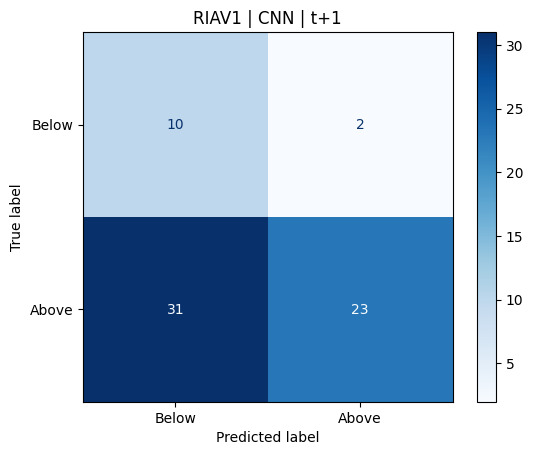

t+2: acc=0.455, prec=0.909, rec=0.370, f1=0.526
              precision    recall  f1-score   support

           0      0.227     0.833     0.357        12
           1      0.909     0.370     0.526        54

    accuracy                          0.455        66
   macro avg      0.568     0.602     0.442        66
weighted avg      0.785     0.455     0.496        66



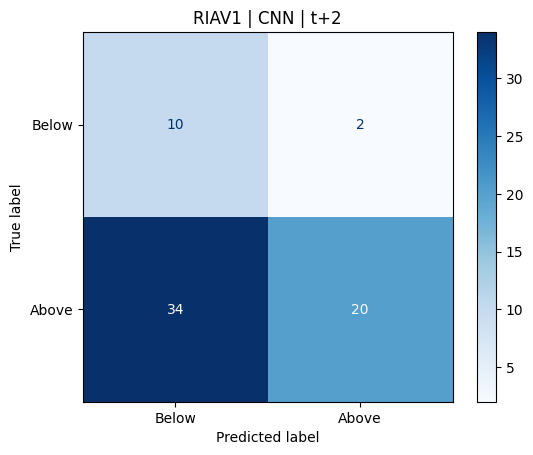

t+3: acc=0.409, prec=0.895, rec=0.315, f1=0.466
              precision    recall  f1-score   support

           0      0.213     0.833     0.339        12
           1      0.895     0.315     0.466        54

    accuracy                          0.409        66
   macro avg      0.554     0.574     0.402        66
weighted avg      0.771     0.409     0.443        66



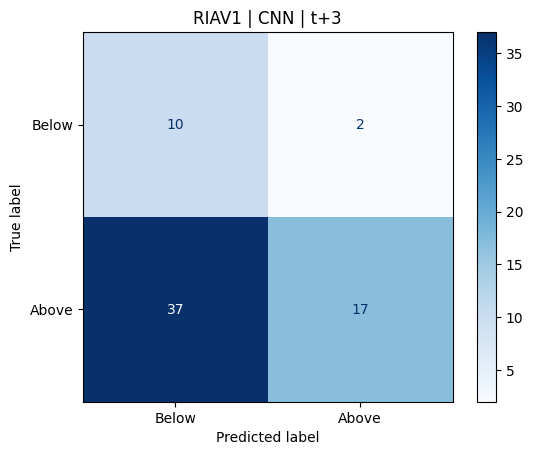

t+4: acc=0.394, prec=0.889, rec=0.296, f1=0.444
              precision    recall  f1-score   support

           0      0.208     0.833     0.333        12
           1      0.889     0.296     0.444        54

    accuracy                          0.394        66
   macro avg      0.549     0.565     0.389        66
weighted avg      0.765     0.394     0.424        66



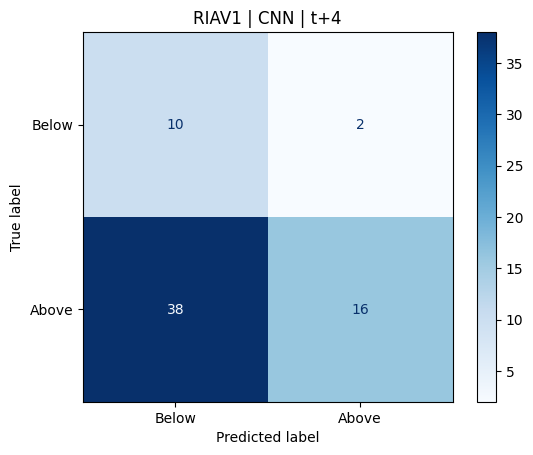


===== MLP Evaluation for RIAV1 =====
t+1: acc=0.788, prec=0.917, rec=0.815, f1=0.863
              precision    recall  f1-score   support

           0      0.444     0.667     0.533        12
           1      0.917     0.815     0.863        54

    accuracy                          0.788        66
   macro avg      0.681     0.741     0.698        66
weighted avg      0.831     0.788     0.803        66



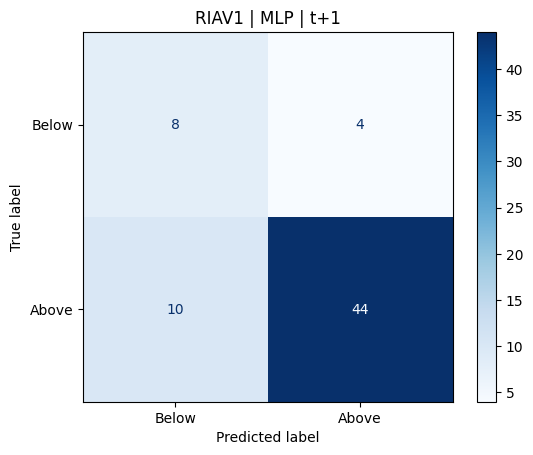

t+2: acc=0.727, prec=0.891, rec=0.759, f1=0.820
              precision    recall  f1-score   support

           0      0.350     0.583     0.438        12
           1      0.891     0.759     0.820        54

    accuracy                          0.727        66
   macro avg      0.621     0.671     0.629        66
weighted avg      0.793     0.727     0.750        66



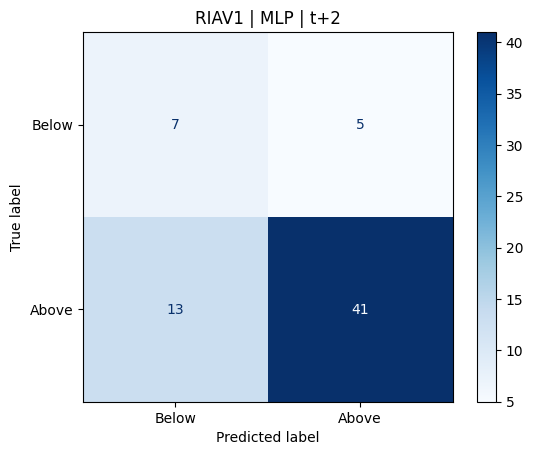

t+3: acc=0.697, prec=0.886, rec=0.722, f1=0.796
              precision    recall  f1-score   support

           0      0.318     0.583     0.412        12
           1      0.886     0.722     0.796        54

    accuracy                          0.697        66
   macro avg      0.602     0.653     0.604        66
weighted avg      0.783     0.697     0.726        66



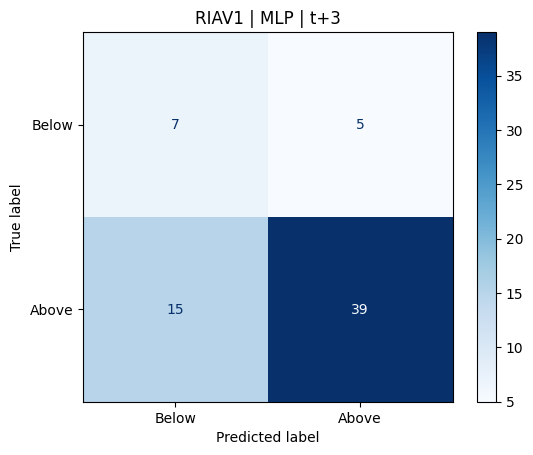

t+4: acc=0.591, prec=0.865, rec=0.593, f1=0.703
              precision    recall  f1-score   support

           0      0.241     0.583     0.341        12
           1      0.865     0.593     0.703        54

    accuracy                          0.591        66
   macro avg      0.553     0.588     0.522        66
weighted avg      0.752     0.591     0.638        66



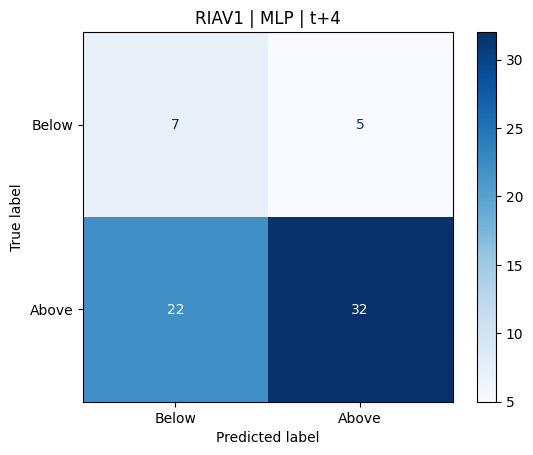

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score

SITE_ID = "RIAV1"
THRESHOLD = 0.5

# Mask the site
mask = (site_ids_test == SITE_ID)
X_site_cnn = X_test_cnn[mask]
X_site_mlp = X_test_mlp[mask]
y_site     = y_test[mask]
dates_site = dates_test[mask]

# --- Predictions ---
y_pred_cnn = (cnn_model.predict(X_site_cnn) >= THRESHOLD).astype(int)
y_pred_mlp = (mlp_model.predict(X_site_mlp) >= THRESHOLD).astype(int)

# --- Evaluation per horizon ---
for model_name, y_pred in zip(["CNN", "MLP"], [y_pred_cnn, y_pred_mlp]):
    print(f"\n===== {model_name} Evaluation for {SITE_ID} =====")
    metrics = []
    for h in range(HORIZON):
        y_t = y_site[:, h]
        y_p = y_pred[:, h]

        acc = accuracy_score(y_t, y_p)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        f1 = f1_score(y_t, y_p, zero_division=0)
        metrics.append({"horizon": f"t+{h+1}", "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})

        print(f"t+{h+1}: acc={acc:.3f}, prec={prec:.3f}, rec={rec:.3f}, f1={f1:.3f}")
        print(classification_report(y_t, y_p, digits=3))

        # Confusion matrix
        cm = confusion_matrix(y_t, y_p, labels=[0,1])
        disp = ConfusionMatrixDisplay(cm, display_labels=["No","Yes"])
        disp.plot(cmap=plt.cm.Blues, values_format='d')
        plt.title(f"{SITE_ID} | {model_name} | t+{h+1}")
        plt.show()
